# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

## Problem 1: Understanding the Data

After reading the UCI documentation below are the details:

**About the Dataset:**
The data is related to direct marketing campaigns of a Portuguese banking institution. The marketing campaigns were based on phone 
calls. Often, more than one contact to the same client was required to determine if the product (bank term deposit) would be subscribed.

**There are four versions of this dataset:**
- bank-additional-full.csv — all 41,188 examples with 20 inputs 
- bank-additional.csv — 10% sample with 20 inputs
- bank-full.csv — all examples with 17 inputs (older version)
- bank.csv — 10% sample with 17 inputs (older version)

**Data Collection Period:**
The data was collected from May 2008 to November 2010.

**The Classification Goal:**
Predict whether a client will subscribe to a term deposit — this is a binary classification problem where y = 'yes' or 'no'

**Key Note on Duration Feature:**
The duration feature (call length in seconds) should be discarded for a realistic model since it is not known before the call is made. 
We will drop this feature during data preparation.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [1]:
import pandas as pd

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import time

# Read in the dataset
# Note: this dataset uses semicolons as separators
df = pd.read_csv('data/bank-additional-full.csv', sep=';')

print("Shape:", df.shape)
df.head()

Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [6]:
# Let's look at the data types and check for missing values
print("Data Types:")
print(df.dtypes)

Data Types:
age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object


In [7]:
# Checking for missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [8]:
# Let's see how balanced our target variable is
print("Target variable distribution:")
print(df['y'].value_counts())
print("\nTarget variable percentage:")
print(df['y'].value_counts(normalize=True) * 100)

Target variable distribution:
y
no     36548
yes     4640
Name: count, dtype: int64

Target variable percentage:
y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


In [9]:
# Statistical summary of numerical columns
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


After examining the data:

## Problem 3: Understanding the Features

After examining the data:

1. **No missing values** — all 41,188 records are complete with no nulls across all 20 features

2. **Mixed data types** — numerical features include age,  duration, campaign, pdays etc. Categorical features include job, marital, education, contact etc. Categorical columns will need to be encoded before modeling

3. **Heavily imbalanced target** — 88.73% of clients said 'no' and only 11.27% said 'yes'. This means if we just predicted 
   'no' for everyone we would get 88.73% accuracy without learning anything useful — so accuracy alone is not a good metric here

4. **Duration feature** — as noted in the documentation,  duration should be dropped for a realistic model since the call length is not known before the call is made

5. **pdays** — the mean of 962 and 75th percentile of 999 confirms that most clients (999 = not previously contacted) were not contacted in a previous campaign

6. **Campaign** — on average clients were contacted about 2.6 times with a max of 56 which suggests some outliers

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

## Problem 4: Understanding the Task — Business Objective

### Business Objective
A Portuguese banking institution wants to improve the efficiency of their telephone marketing campaigns. Currently they contact 
a large number of clients but only a small percentage subscribe to the term deposit product — just 11.27% based on our data.

### Data Problem Definition
This is a binary classification problem where the goal is to predict whether a client will subscribe to a term deposit 
(y = 'yes') or not (y = 'no') based on client information and campaign details.

By building a model that accurately identifies clients most likely to subscribe, the bank can:
- Focus their calling efforts on high probability customers
- Reduce wasted calls on unlikely subscribers
- Improve overall campaign conversion rates
- Save time and resources

### Key Challenge
The dataset is heavily imbalanced — 88.73% said 'no' and only 11.27% said 'yes'. This means accuracy alone is not a good metric. We need to also look at precision and recall to make 
sure our model is actually finding likely subscribers and not just predicting 'no' for everyone.

### Success Criteria
A successful model will:
- Outperform the baseline accuracy of 88.73%
- Have strong recall for the 'yes' class so the bank does not miss potential subscribers
- Be interpretable enough for the marketing team to act on

/var/folders/gs/wpn3djhs7djc9xjsdkxcgsgm0000gn/T/ipykernel_38283/3626355511.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='y', palette='Set2')


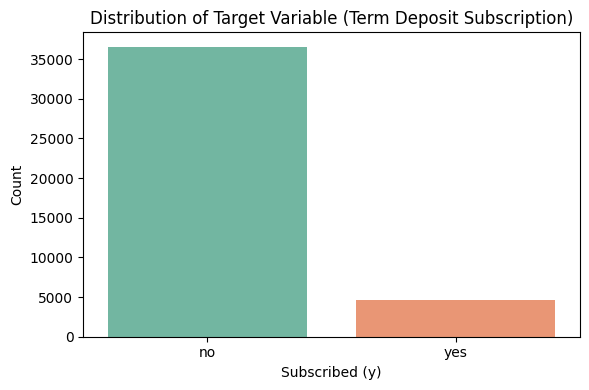

No: 36548 (88.73%)
Yes: 4640 (11.27%)


In [11]:
# Visualizing the class imbalance
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='y', palette='Set2')
plt.title('Distribution of Target Variable (Term Deposit Subscription)')
plt.xlabel('Subscribed (y)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f"No: {df['y'].value_counts()['no']} ({df['y'].value_counts(normalize=True)['no']*100:.2f}%)")
print(f"Yes: {df['y'].value_counts()['yes']} ({df['y'].value_counts(normalize=True)['yes']*100:.2f}%)")

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

Below are the features for modeling and steps:
- Drop the duration column as it is not known before the call
- Encode categorical features using OneHotEncoder
- Scale numerical features using StandardScaler
- Use only the bank client information features as instructed

In [12]:
# Drop duration as it is not a realistic predictor
# It is only known after the call ends
df_model = df.drop(columns=['duration'])

# Encode target variable as binary
df_model['y'] = df_model['y'].map({'yes': 1, 'no': 0})

print("Shape after dropping duration:", df_model.shape)
print("\nTarget variable encoded:")
print(df_model['y'].value_counts())

Shape after dropping duration: (41188, 20)

Target variable encoded:
y
0    36548
1     4640
Name: count, dtype: int64


In [13]:
# Define features and target
X = df_model.drop(columns=['y'])
y = df_model['y']

# Identify categorical and numerical columns
cat_features = X.select_dtypes(include='object').columns.tolist()
num_features = X.select_dtypes(include='number').columns.tolist()

print("Numerical features:", num_features)
print("\nCategorical features:", cat_features)

Numerical features: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


/var/folders/gs/wpn3djhs7djc9xjsdkxcgsgm0000gn/T/ipykernel_38283/90216388.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include='object').columns.tolist()


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Scale numerical and encode categorical features
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

print("Preprocessor built successfully!")

Preprocessor built successfully!


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.


Splitting the data into 80% training and 20% test sets. I'm using stratify=y to make sure both splits have the same proportion of yes/no — this is important because our dataset 
is imbalanced.

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training set size: (32950, 19)
Test set size: (8238, 19)

Training target distribution:
y
0    88.734446
1    11.265554
Name: proportion, dtype: float64

Test target distribution:
y
0    88.73513
1    11.26487
Name: proportion, dtype: float64


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

Since 88.73% of clients said 'no', a model that always predicts 'no' would be right 88.73% of the time without learning anything. 
This is my baseline — any real model needs to beat this AND actually find the 'yes' cases.

In [17]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

# A dummy model that always predicts the majority class
# This gives us our baseline to beat
baseline = DummyClassifier(strategy='most_frequent', random_state=42)
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_pred)

print(f"Baseline accuracy (always predict 'no'): {baseline_accuracy*100:.2f}%")
print("\nAny model we build needs to beat this!")

Baseline accuracy (always predict 'no'): 88.74%

Any model we build needs to beat this!


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

Below is  Logistic Regression used to build a basic model on your data

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Build Logistic Regression pipeline
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

# Fit and score
start = time.time()
pipeline_lr.fit(X_train, y_train)
train_time = time.time() - start

train_acc = accuracy_score(y_train, pipeline_lr.predict(X_train))
test_acc = accuracy_score(y_test, pipeline_lr.predict(X_test))

print(f"Train Time:      {train_time:.2f}s")
print(f"Train Accuracy:  {train_acc*100:.2f}%")
print(f"Test Accuracy:   {test_acc*100:.2f}%")

Train Time:      0.65s
Train Accuracy:  89.99%
Test Accuracy:   90.09%


### Problem 9: Score the Model

What is the accuracy of your model?

The Logistic Regression model achieved a test accuracy of 90.09% which beats our baseline of 88.74%. However accuracy alone is 
not enough given the class imbalance — checking further how well it identifies the 'yes' cases.

Classification Report:
              precision    recall  f1-score   support

          No       0.91      0.99      0.95      7310
         Yes       0.69      0.22      0.33       928

    accuracy                           0.90      8238
   macro avg       0.80      0.60      0.64      8238
weighted avg       0.88      0.90      0.88      8238



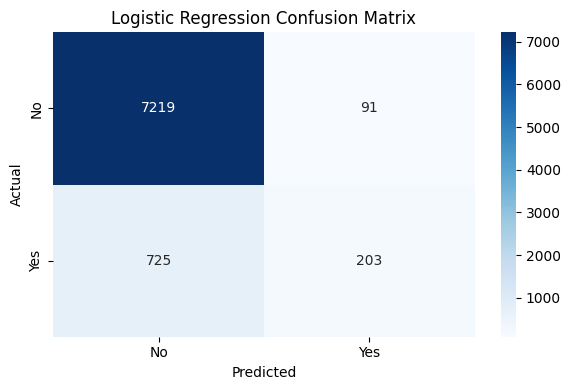

In [19]:
from sklearn.metrics import classification_report, confusion_matrix

# Detailed scoring
y_pred_lr = pipeline_lr.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['No', 'Yes']))

# Confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), 
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### Observations

The model gets 90.09% overall accuracy which beats the baseline of 88.74% — but looking closer at the classification report 
tells a more concerning story:
- **'No' class:** precision 91%, recall 99% — almost perfect
- **'Yes' class:** precision 69%, recall only 22% — very poor

This means the model is only catching 22% of actual subscribers and missing 78% of them. For the bank this is a big problem 
— they are missing most of the customers who would actually say yes to the product.

This confirms that accuracy alone is misleading here. We need to improve recall for the 'yes' class. Let's see if the other models do better.

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [20]:
## Problem 10: Model Comparisons

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Store results
results = []

# Models to compare
models = {
    'Logistic Regression': pipeline_lr,
    'KNN': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', KNeighborsClassifier())
    ]),
    'Decision Tree': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(random_state=42))
    ]),
    'SVM': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', SVC(random_state=42))
    ])
}

# Fit and score each model
for name, pipeline in models.items():
    start = time.time()
    pipeline.fit(X_train, y_train)
    train_time = time.time() - start
    
    train_acc = accuracy_score(y_train, pipeline.predict(X_train))
    test_acc = accuracy_score(y_test, pipeline.predict(X_test))
    
    results.append({
        'Model': name,
        'Train Time (s)': round(train_time, 2),
        'Train Accuracy': round(train_acc * 100, 2),
        'Test Accuracy': round(test_acc * 100, 2)
    })
    print(f"{name} done!")

# Display results
results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df)

Logistic Regression done!
KNN done!
Decision Tree done!
SVM done!

Model Comparison:
                 Model  Train Time (s)  Train Accuracy  Test Accuracy
0  Logistic Regression            0.49           89.99          90.09
1                  KNN            0.11           91.22          89.72
2        Decision Tree            0.45           99.54          84.18
3                  SVM          165.62           90.50          90.35


## Problem 10: Model Comparisons

### Results

| Model | Train Time | Train Accuracy | Test Accuracy |
|---|---|---|---|
| Logistic Regression | 0.49s | 89.99% | 90.09% |
| KNN | 0.11s | 91.22% | 89.72% |
| Decision Tree | 0.45s | 99.54% | 84.18% |
| SVM | 165.62s | 90.50% | 90.35% |

### Observations

1. **SVM** achieved the highest test accuracy at 90.35% but took 165 seconds to train — by far the slowest model

2. **Logistic Regression** performed nearly as well as SVM at 90.09% but trained in just 0.49 seconds — much more practical for real use

3. **KNN** was the fastest to train at 0.11 seconds but slightly underperformed on the test set suggesting some overfitting

4. **Decision Tree** is clearly overfitting — train accuracy of 99.54% vs test accuracy of 84.18% is a big gap. The tree has memorized the training data rather than learning 
   general patterns

5. **All models beat the baseline** of 88.74% except Decision Tree on the test set

### Key Takeaway
Accuracy alone still doesn't tell the full story given the class imbalance. In the next step we will tune the models and look at better metrics for this problem.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

Now to improve on the baseline models by:
1. Tuning hyperparameters using GridSearchCV
2. Using a better metric — I'll use recall for the 'yes' class since the bank cares most about finding subscribers and not missing them

In [21]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# Tuning Logistic Regression
pipeline_lr_tuned = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

param_grid_lr = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__solver': ['lbfgs', 'liblinear']
}

gs_lr = GridSearchCV(
    pipeline_lr_tuned, param_grid_lr,
    cv=3, scoring='recall', verbose=1
)
gs_lr.fit(X_train, y_train)

print("Best params:", gs_lr.best_params_)
print("Best CV Recall:", gs_lr.best_score_.round(4))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'model__C': 10, 'model__solver': 'lbfgs'}
Best CV Recall: 0.2319


In [22]:
# Tuning KNN - finding the best K
pipeline_knn_tuned = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier())
])

param_grid_knn = {
    'model__n_neighbors': [3, 5, 7, 9, 11],
    'model__weights': ['uniform', 'distance']
}

gs_knn = GridSearchCV(
    pipeline_knn_tuned, param_grid_knn,
    cv=3, scoring='recall', verbose=1
)
gs_knn.fit(X_train, y_train)

print("Best params:", gs_knn.best_params_)
print("Best CV Recall:", gs_knn.best_score_.round(4))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'model__n_neighbors': 3, 'model__weights': 'distance'}
Best CV Recall: 0.295


In [23]:
# Tuning Decision Tree - controlling depth to fix overfitting
pipeline_dt_tuned = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

param_grid_dt = {
    'model__max_depth': [3, 5, 7, 10],
    'model__min_samples_split': [2, 5, 10]
}

gs_dt = GridSearchCV(
    pipeline_dt_tuned, param_grid_dt,
    cv=3, scoring='recall', verbose=1
)
gs_dt.fit(X_train, y_train)

print("Best params:", gs_dt.best_params_)
print("Best CV Recall:", gs_dt.best_score_.round(4))

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'model__max_depth': 5, 'model__min_samples_split': 10}
Best CV Recall: 0.2707


In [24]:
# Tuning SVM - using a small sample to keep it fast
sample = X_train.sample(n=10000, random_state=42)
y_sample = y_train.loc[sample.index]

pipeline_svm_tuned = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SVC(random_state=42))
])

param_grid_svm = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['rbf', 'linear']
}

gs_svm = GridSearchCV(
    pipeline_svm_tuned, param_grid_svm,
    cv=3, scoring='recall', verbose=1
)
gs_svm.fit(sample, y_sample)

print("Best params:", gs_svm.best_params_)
print("Best CV Recall:", gs_svm.best_score_.round(4))

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best params: {'model__C': 10, 'model__kernel': 'rbf'}
Best CV Recall: 0.2524


In [25]:
# Compare all tuned models on test set
tuned_models = {
    'Logistic Regression': gs_lr,
    'KNN': gs_knn,
    'Decision Tree': gs_dt,
    'SVM': gs_svm
}

tuned_results = []

for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, 
                                   output_dict=True)
    recall_yes = report['1']['recall']
    precision_yes = report['1']['precision']
    f1_yes = report['1']['f1-score']
    
    tuned_results.append({
        'Model': name,
        'Test Accuracy': round(acc * 100, 2),
        'Recall (Yes)': round(recall_yes * 100, 2),
        'Precision (Yes)': round(precision_yes * 100, 2),
        'F1 (Yes)': round(f1_yes * 100, 2)
    })
    print(f"{name} done!")

tuned_results_df = pd.DataFrame(tuned_results)
print("\nTuned Model Comparison:")
print(tuned_results_df)

Logistic Regression done!
KNN done!
Decision Tree done!
SVM done!

Tuned Model Comparison:
                 Model  Test Accuracy  Recall (Yes)  Precision (Yes)  F1 (Yes)
0  Logistic Regression          90.08         21.88            68.81     33.20
1                  KNN          87.87         31.90            44.65     37.21
2        Decision Tree          90.25         24.89            68.55     36.52
3                  SVM          89.66         26.94            58.96     36.98


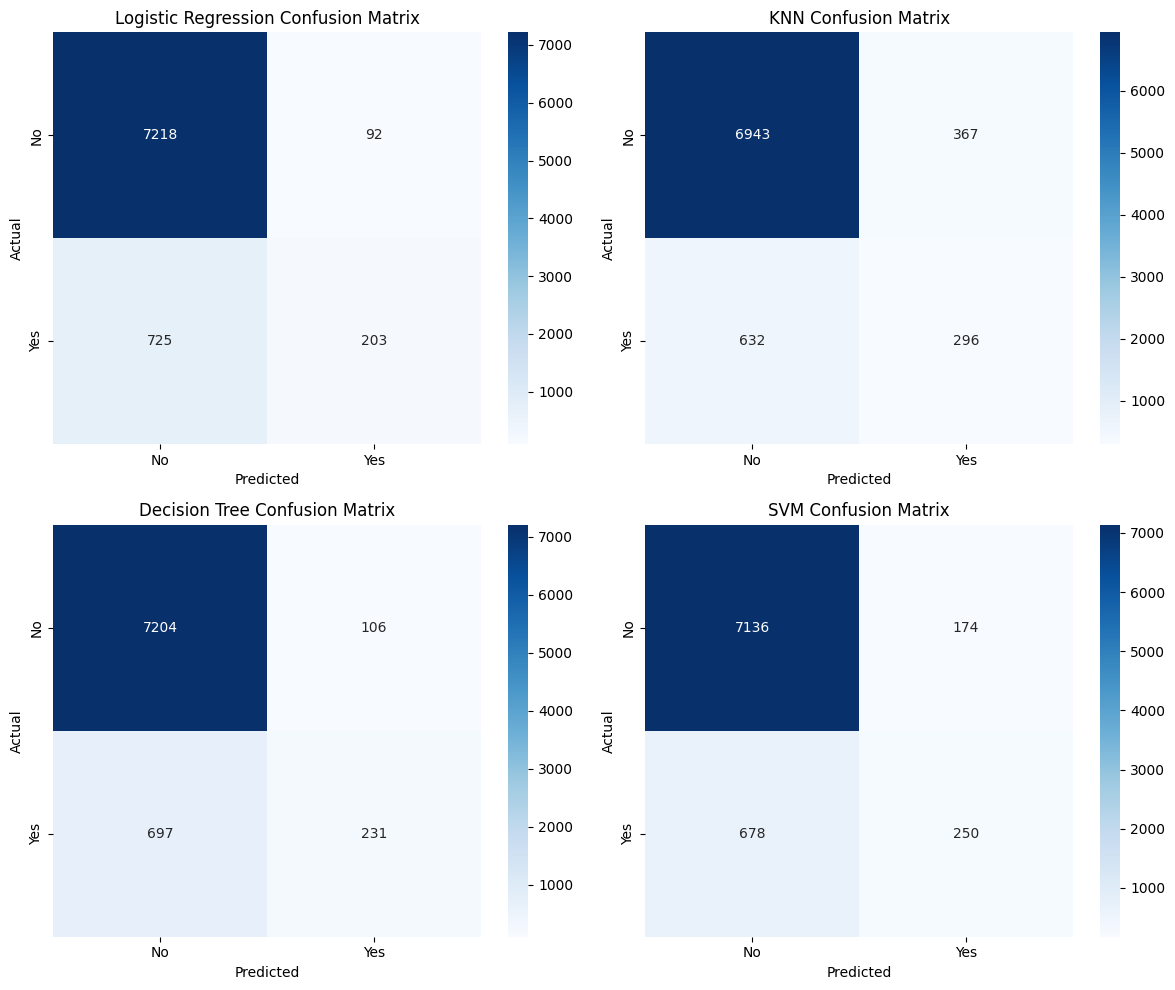

In [26]:
# Visualize confusion matrices for all tuned models
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (name, model) in zip(axes.flatten(), tuned_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No', 'Yes'],
                yticklabels=['No', 'Yes'])
    ax.set_title(f'{name} Confusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

#### Tuned Model Comparison

| Model | Test Accuracy | Recall (Yes) | Precision (Yes) | F1 (Yes) |
|---|---|---|---|---|
| Logistic Regression | 90.08% | 21.88% | 68.81% | 33.20% |
| KNN | 87.87% | 31.90% | 44.65% | 37.21% |
| Decision Tree | 90.25% | 24.89% | 68.55% | 36.52% |
| SVM | 89.66% | 26.94% | 58.96% | 36.98% |
| **Baseline** | **88.74%** | **0%** | **0%** | **0%** |

#### Observations

1. **KNN has the best recall at 31.90%** — it finds the most actual subscribers out of all models. For the bank this 
   is the most important metric since missing a subscriber is more costly than calling a non-subscriber

2. **Decision Tree has the best accuracy at 90.25%** and tuning with max_depth=5 fixed the overfitting we saw earlier (train accuracy was 99.54% before tuning)

3. **Logistic Regression has the best precision at 68.81%** 
   — when it predicts 'yes' it is right 68.81% of the time but it misses too many actual subscribers

4. **Recall scores are still low across all models** — this is a challenging imbalanced dataset and all models struggle to find the 'yes' cases

#### Best Model Recommendation
**KNN with n_neighbors=3 and distance weighting** is the best model for this business problem because it has the highest recall (31.90%) meaning it identifies the most 
potential subscribers — which is what the bank cares about most.

#### Why Recall over Accuracy?
For this business problem, missing a potential subscriber (false negative) is more costly than calling a non-subscriber (false positive). The bank wastes one phone call on a false 
positive but loses a potential customer on a false negative. Therefore recall is the most appropriate metric to optimize.

## Findings and Recommendations

### Summary for the Bank

We analyzed 41,188 telephone marketing campaign records and built four classification models to predict which customers 
are likely to subscribe to a term deposit.

### Key Findings

1. **The dataset is heavily imbalanced** — only 11.27% of customers subscribed. This means accuracy alone is misleading and recall is the more important metric.

2. **KNN is the best model** for this problem with the highest recall of 31.90% — it correctly identified 296 out of 928 actual subscribers in the test set.

3. **All models struggled with the 'yes' class** — even the best model only caught about 1 in 3 subscribers. This is a challenging imbalanced classification problem.

4. **Decision Tree overfitting was fixed** by limiting max_depth to 5 — bringing test accuracy from 84% back up to 90.25%.

### Recommendations for the Bank

1. **Use KNN to prioritize calling lists** — focus calls on customers the model predicts as likely subscribers to improve campaign efficiency

2. **Do not rely on accuracy as a metric** — with 88.74% of customers saying no, accuracy is misleading. Focus on recall and precision for the 'yes' class

3. **Collect more data on subscribers** — the model struggles because there are very few 'yes' examples. More subscriber data would improve performance

4. **Consider the timing of calls** — features like month and day of week may reveal optimal times to contact customers

### Next Steps

1. Try resampling techniques like SMOTE to handle the class imbalance
2. Explore ensemble methods like Random Forest in future modules
3. Collect more complete data on previous campaign outcomes
4. Test the KNN model on new campaign data before fully deploying it

##### Questions